# Family-fix double check

This notebook performs the **final double check** for the family-fix calibration runs saved in the local results folder.

It does the following:

1. loads all replications from the results directory,
2. builds the deployed hit matrix from `deploy_final_rep*.csv`,
3. computes the pointwise empirical coverage of the **actual deployed intervals**,
4. optionally compares it against the split-bootstrap estimated coverage at the selected `alpha_star(x)`,
5. saves summary tables and plots back to a local output folder.

The notebook assumes the results were produced by:

`svgp_twosplit_bootstrap_familyfix_full_deploy.py`


In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 160

RESULTS_DIR = Path(r"C:\Users\yangy\26 spring\with reference\familyfix\results")
OUTPUT_DIR = RESULTS_DIR / "double_check_summary"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR, OUTPUT_DIR

(WindowsPath('C:/Users/yangy/26 spring/with reference/familyfix/results'),
 WindowsPath('C:/Users/yangy/26 spring/with reference/familyfix/results/double_check_summary'))

In [2]:
DEPLOY_PATTERN = "deploy_final_rep*_J*.csv"
COVERAGE_PATTERN = "pointwise_coverage_rep*_A*_B*.csv"
ALPHA_STAR_PATTERN = "alpha_star_curve_rep*.csv"
META_PATTERN = "meta_rep*.json"

rep_regex = re.compile(r"rep(\d+)")

def parse_rep_id(path: Path) -> int:
    m = rep_regex.search(path.stem)
    if m is None:
        raise ValueError(f"Could not parse rep id from {path.name}")
    return int(m.group(1))

deploy_files = sorted(RESULTS_DIR.glob(DEPLOY_PATTERN), key=parse_rep_id)
coverage_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(COVERAGE_PATTERN)}
alpha_star_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(ALPHA_STAR_PATTERN)}
meta_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(META_PATTERN)}

print(f"Found {len(deploy_files)} deploy files")
print(f"Found {len(coverage_files)} pointwise coverage files")
print(f"Found {len(alpha_star_files)} alpha-star files")
print(f"Found {len(meta_files)} meta files")

if len(deploy_files) == 0:
    raise FileNotFoundError(f"No files matching {DEPLOY_PATTERN} were found in {RESULTS_DIR}")

Found 100 deploy files
Found 100 pointwise coverage files
Found 100 alpha-star files
Found 100 meta files


In [3]:
def load_optional_json(path: Path):
    if path is None or not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def selected_estimated_coverage(coverage_df: pd.DataFrame, alpha_star_vec: np.ndarray) -> np.ndarray:
    out = np.empty(len(alpha_star_vec), dtype=float)
    for j, a in enumerate(alpha_star_vec):
        col = f"alpha_{float(a):.4f}"
        if col not in coverage_df.columns:
            alpha_cols = [c for c in coverage_df.columns if c.startswith("alpha_")]
            alpha_vals = np.array([float(c.split("_", 1)[1]) for c in alpha_cols], dtype=float)
            idx = int(np.argmin(np.abs(alpha_vals - float(a))))
            col = alpha_cols[idx]
        out[j] = float(coverage_df.iloc[j][col])
    return out

records = []
x_ref = None
true_f_ref = None
ci_level = None

for deploy_path in deploy_files:
    rep_id = parse_rep_id(deploy_path)
    deploy_df = pd.read_csv(deploy_path).sort_values("x").reset_index(drop=True)

    if x_ref is None:
        x_ref = deploy_df["x"].to_numpy(dtype=float)
        true_f_ref = deploy_df["true_f"].to_numpy(dtype=float)
    else:
        if not np.allclose(x_ref, deploy_df["x"].to_numpy(dtype=float)):
            raise ValueError(f"x-grid mismatch in rep {rep_id}")
        if not np.allclose(true_f_ref, deploy_df["true_f"].to_numpy(dtype=float)):
            raise ValueError(f"true_f mismatch in rep {rep_id}")

    meta = load_optional_json(meta_files.get(rep_id))
    if meta is not None and ci_level is None:
        ci_level = float(meta.get("ci_level", np.nan))

    rec = {
        "rep_id": rep_id,
        "deploy_path": deploy_path,
        "deploy_df": deploy_df,
        "meta": meta,
        "coverage_df": None,
        "alpha_star_df": None,
        "selected_est_cov": None,
    }

    cov_path = coverage_files.get(rep_id)
    if cov_path is not None:
        cov_df = pd.read_csv(cov_path).sort_values("x").reset_index(drop=True)
        if not np.allclose(x_ref, cov_df["x"].to_numpy(dtype=float)):
            raise ValueError(f"coverage x-grid mismatch in rep {rep_id}")
        rec["coverage_df"] = cov_df

    alpha_path = alpha_star_files.get(rep_id)
    if alpha_path is not None:
        alpha_df = pd.read_csv(alpha_path).sort_values("x").reset_index(drop=True)
        if not np.allclose(x_ref, alpha_df["x"].to_numpy(dtype=float)):
            raise ValueError(f"alpha_star x-grid mismatch in rep {rep_id}")
        rec["alpha_star_df"] = alpha_df

    if rec["coverage_df"] is not None:
        if rec["alpha_star_df"] is not None:
            alpha_star_vec = rec["alpha_star_df"]["alpha_star"].to_numpy(dtype=float)
        else:
            alpha_star_vec = deploy_df["alpha_star"].to_numpy(dtype=float)
        rec["selected_est_cov"] = selected_estimated_coverage(rec["coverage_df"], alpha_star_vec)

    records.append(rec)

print(f"Loaded {len(records)} replications")
print(f"Nominal CI level from meta: {ci_level}")

Loaded 100 replications
Nominal CI level from meta: 0.95


In [4]:
rep_ids = np.array([r["rep_id"] for r in records], dtype=int)
R = len(records)
J = len(x_ref)

hit_mat = np.vstack([r["deploy_df"]["hit"].to_numpy(dtype=float) for r in records])
alpha_star_mat = np.vstack([r["deploy_df"]["alpha_star"].to_numpy(dtype=float) for r in records])
mu_mat = np.vstack([r["deploy_df"]["mu"].to_numpy(dtype=float) for r in records])
lower_mat = np.vstack([r["deploy_df"]["lower"].to_numpy(dtype=float) for r in records])
upper_mat = np.vstack([r["deploy_df"]["upper"].to_numpy(dtype=float) for r in records])

have_est_cov = all(r["selected_est_cov"] is not None for r in records)
if have_est_cov:
    est_cov_selected_mat = np.vstack([r["selected_est_cov"] for r in records])
else:
    est_cov_selected_mat = None

summary = {
    "R": int(R),
    "J": int(J),
    "rep_id_min": int(rep_ids.min()),
    "rep_id_max": int(rep_ids.max()),
    "nominal": float(ci_level) if ci_level is not None else np.nan,
    "overall_deploy_mean_hit": float(hit_mat.mean()),
    "rep_mean_hit_mean": float(hit_mat.mean(axis=1).mean()),
    "rep_mean_hit_sd": float(hit_mat.mean(axis=1).std(ddof=1)) if R > 1 else 0.0,
}

if have_est_cov:
    summary["overall_selected_est_cov_mean"] = float(est_cov_selected_mat.mean())
    summary["overall_deploy_minus_est_mean"] = float(hit_mat.mean() - est_cov_selected_mat.mean())

summary

{'R': 100,
 'J': 50,
 'rep_id_min': 0,
 'rep_id_max': 99,
 'nominal': 0.95,
 'overall_deploy_mean_hit': 0.976,
 'rep_mean_hit_mean': 0.9760000000000001,
 'rep_mean_hit_sd': 0.06023522912949555,
 'overall_selected_est_cov_mean': 0.9857080000000001,
 'overall_deploy_minus_est_mean': -0.009708000000000161}

In [5]:
pointwise_deploy_cov = hit_mat.mean(axis=0)
pointwise_deploy_sd = hit_mat.std(axis=0, ddof=1) if R > 1 else np.zeros(J)
pointwise_deploy_se = pointwise_deploy_sd / np.sqrt(max(R, 1))

pointwise_alpha_star_mean = alpha_star_mat.mean(axis=0)
pointwise_alpha_star_sd = alpha_star_mat.std(axis=0, ddof=1) if R > 1 else np.zeros(J)

pointwise_table = pd.DataFrame({
    "x": x_ref,
    "true_f": true_f_ref,
    "deploy_coverage": pointwise_deploy_cov,
    "deploy_sd_across_rep_hits": pointwise_deploy_sd,
    "deploy_se": pointwise_deploy_se,
    "alpha_star_mean": pointwise_alpha_star_mean,
    "alpha_star_sd": pointwise_alpha_star_sd,
})

if ci_level is not None:
    pointwise_table["nominal"] = float(ci_level)
    pointwise_table["deploy_minus_nominal"] = pointwise_table["deploy_coverage"] - float(ci_level)
    pointwise_table["abs_error_to_nominal"] = np.abs(pointwise_table["deploy_minus_nominal"])

if have_est_cov:
    pointwise_est_cov = est_cov_selected_mat.mean(axis=0)
    pointwise_est_cov_sd = est_cov_selected_mat.std(axis=0, ddof=1) if R > 1 else np.zeros(J)
    pointwise_table["selected_est_coverage"] = pointwise_est_cov
    pointwise_table["selected_est_coverage_sd"] = pointwise_est_cov_sd
    pointwise_table["deploy_minus_selected_est"] = pointwise_table["deploy_coverage"] - pointwise_table["selected_est_coverage"]

pointwise_table.head()

,x,true_f,deploy_coverage,deploy_sd_across_rep_hits,deploy_se,alpha_star_mean,alpha_star_sd,nominal,deploy_minus_nominal,abs_error_to_nominal,selected_est_coverage,selected_est_coverage_sd,deploy_minus_selected_est
0,-2.500000,0.173318,0.95,0.219043,0.021904,0.545,0.332841,0.95,0.00,0.00,0.9607,0.029033,-0.0107
1,-2.397959,-0.291511,1.00,0.000000,0.000000,0.919,0.192640,0.95,0.05,0.05,0.9790,0.017552,0.0210
2,-2.295918,-0.547295,0.88,0.326599,0.032660,0.832,0.253811,0.95,-0.07,0.07,0.9707,0.017538,-0.0907
3,-2.193878,-0.460571,0.87,0.337998,0.033800,0.698,0.291281,0.95,-0.08,0.08,0.9644,0.016226,-0.0944
4,-2.091837,-0.045550,1.00,0.000000,0.000000,0.975,0.097830,0.95,0.05,0.05,0.9818,0.017831,0.0182


In [6]:
summary_df = pd.DataFrame([summary])
summary_df.to_csv(OUTPUT_DIR / "double_check_summary.csv", index=False)
pointwise_table.to_csv(OUTPUT_DIR / "double_check_pointwise.csv", index=False)

rep_level_df = pd.DataFrame({
    "rep_id": rep_ids,
    "deploy_mean_hit": hit_mat.mean(axis=1),
    "alpha_star_mean": alpha_star_mat.mean(axis=1),
    "alpha_star_unique_count": [np.unique(alpha_star_mat[i]).size for i in range(R)],
})

if have_est_cov:
    rep_level_df["selected_est_cov_mean"] = est_cov_selected_mat.mean(axis=1)
    rep_level_df["deploy_minus_selected_est_mean"] = rep_level_df["deploy_mean_hit"] - rep_level_df["selected_est_cov_mean"]

rep_level_df.to_csv(OUTPUT_DIR / "double_check_rep_level.csv", index=False)

summary_df

,R,J,rep_id_min,rep_id_max,nominal,overall_deploy_mean_hit,rep_mean_hit_mean,rep_mean_hit_sd,overall_selected_est_cov_mean,overall_deploy_minus_est_mean
0,100,50,0,99,0.95,0.976,0.976,0.060235,0.985708,-0.009708


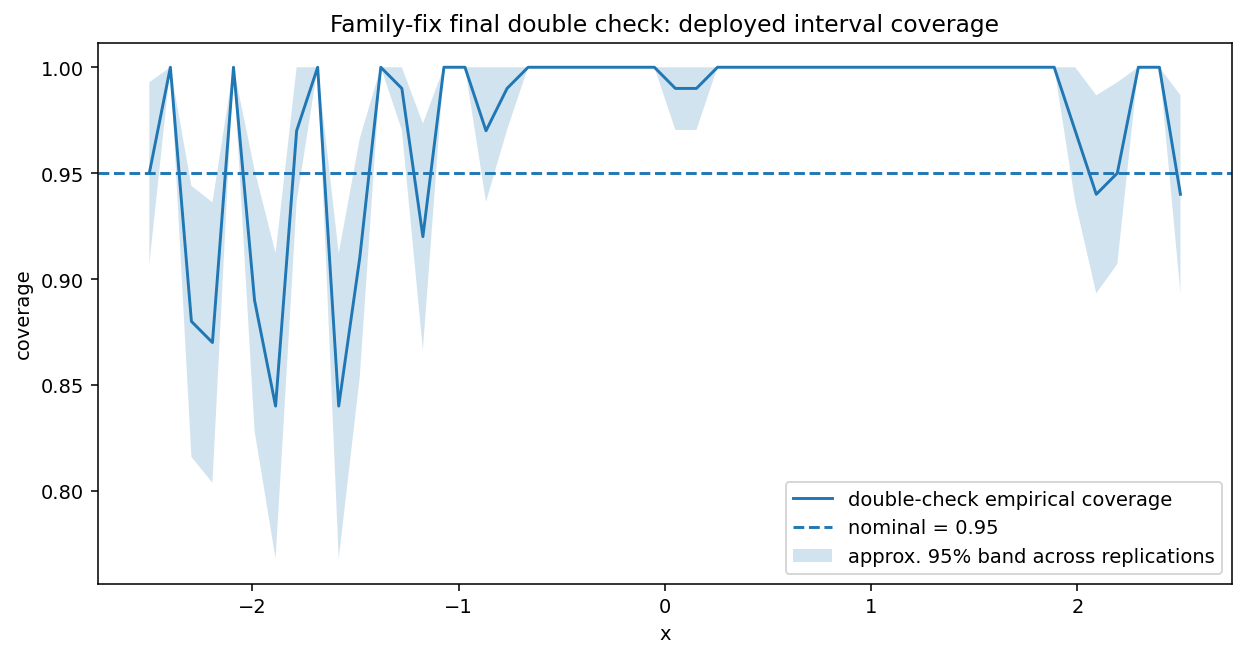

In [7]:
def savefig(name: str):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / name, bbox_inches="tight")
    plt.show()

# 1) Actual deployed pointwise coverage
plt.figure(figsize=(9, 4.8))
plt.plot(x_ref, pointwise_deploy_cov, label="double-check empirical coverage")
if ci_level is not None:
    plt.axhline(float(ci_level), linestyle="--", label=f"nominal = {ci_level:.2f}")
plt.fill_between(
    x_ref,
    np.clip(pointwise_deploy_cov - 1.96 * pointwise_deploy_se, 0.0, 1.0),
    np.clip(pointwise_deploy_cov + 1.96 * pointwise_deploy_se, 0.0, 1.0),
    alpha=0.2,
    label="approx. 95% band across replications",
)
plt.xlabel("x")
plt.ylabel("coverage")
plt.title("Family-fix final double check: deployed interval coverage")
plt.legend()
savefig("01_double_check_coverage.png")

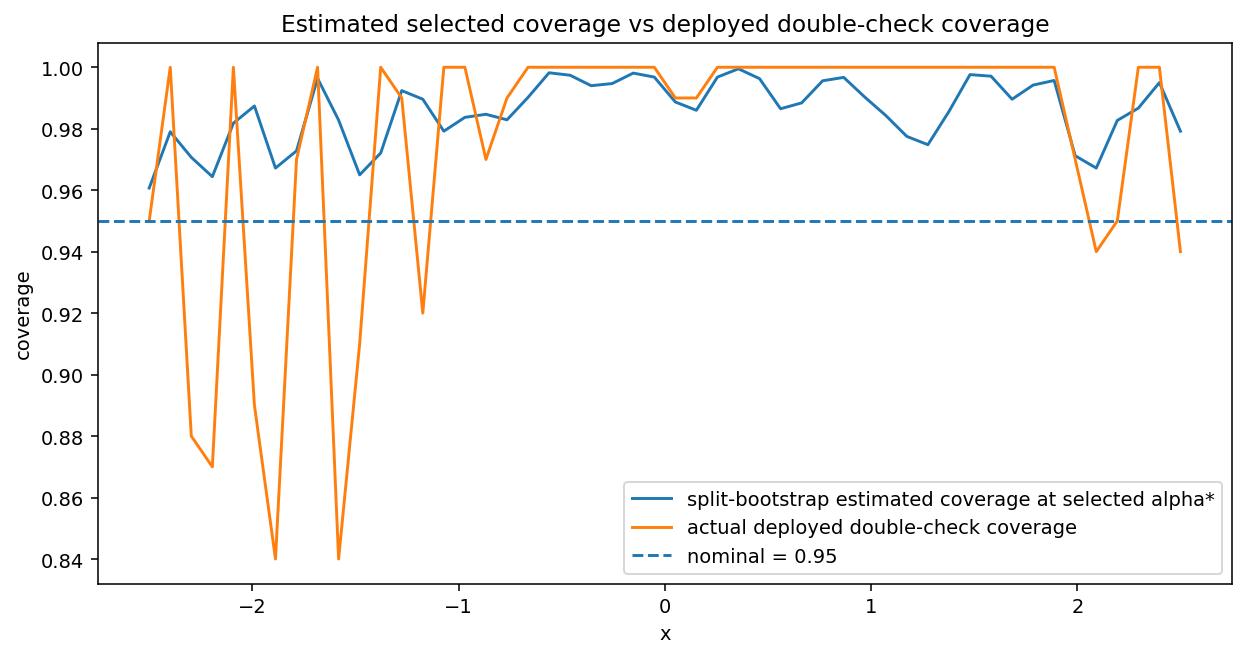

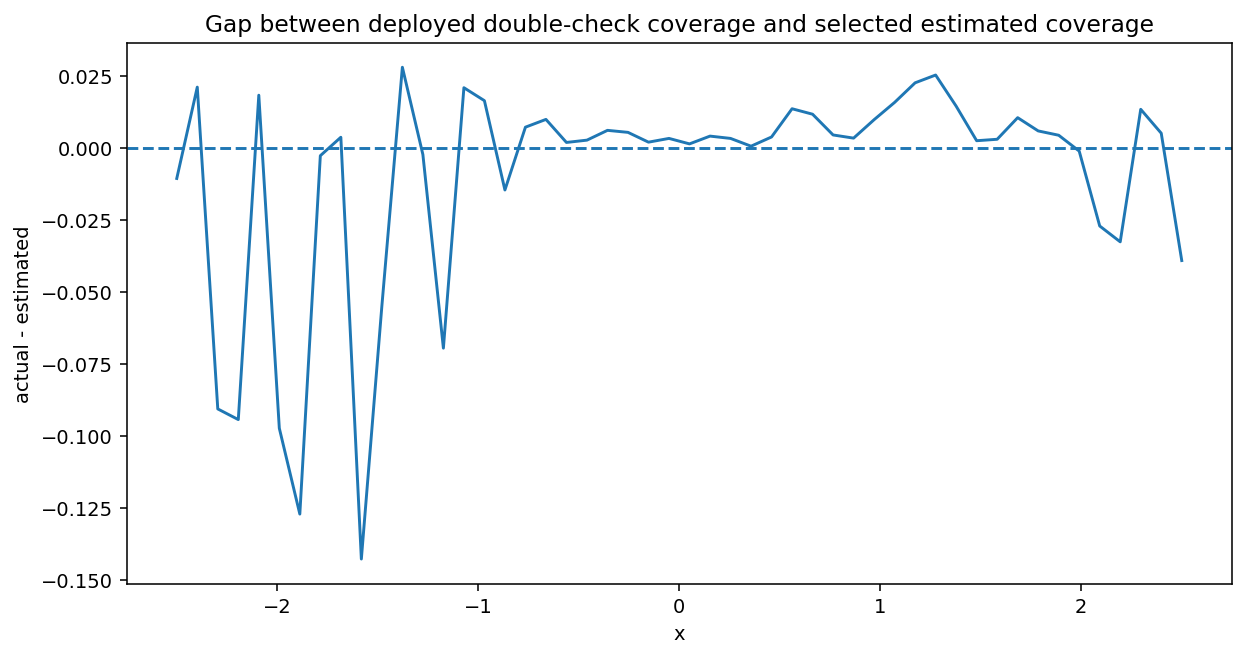

In [8]:
# 2) Compare calibration estimate at selected alpha*(x) vs actual deployed coverage
if have_est_cov:
    plt.figure(figsize=(9, 4.8))
    plt.plot(x_ref, pointwise_table["selected_est_coverage"], label="split-bootstrap estimated coverage at selected alpha*")
    plt.plot(x_ref, pointwise_table["deploy_coverage"], label="actual deployed double-check coverage")
    if ci_level is not None:
        plt.axhline(float(ci_level), linestyle="--", label=f"nominal = {ci_level:.2f}")
    plt.xlabel("x")
    plt.ylabel("coverage")
    plt.title("Estimated selected coverage vs deployed double-check coverage")
    plt.legend()
    savefig("02_estimated_vs_actual_coverage.png")

    plt.figure(figsize=(9, 4.8))
    plt.plot(x_ref, pointwise_table["deploy_minus_selected_est"])
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("x")
    plt.ylabel("actual - estimated")
    plt.title("Gap between deployed double-check coverage and selected estimated coverage")
    savefig("03_actual_minus_estimated_gap.png")
else:
    print("Skipping estimated-vs-actual comparison because some pointwise coverage files are missing.")

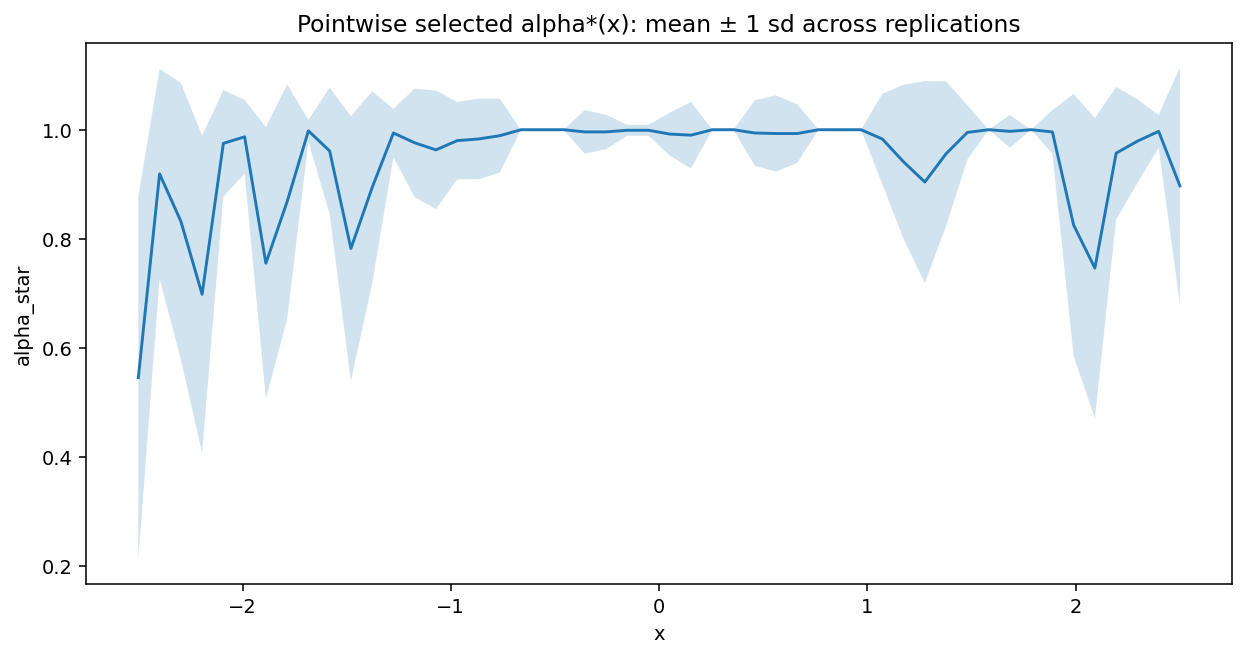

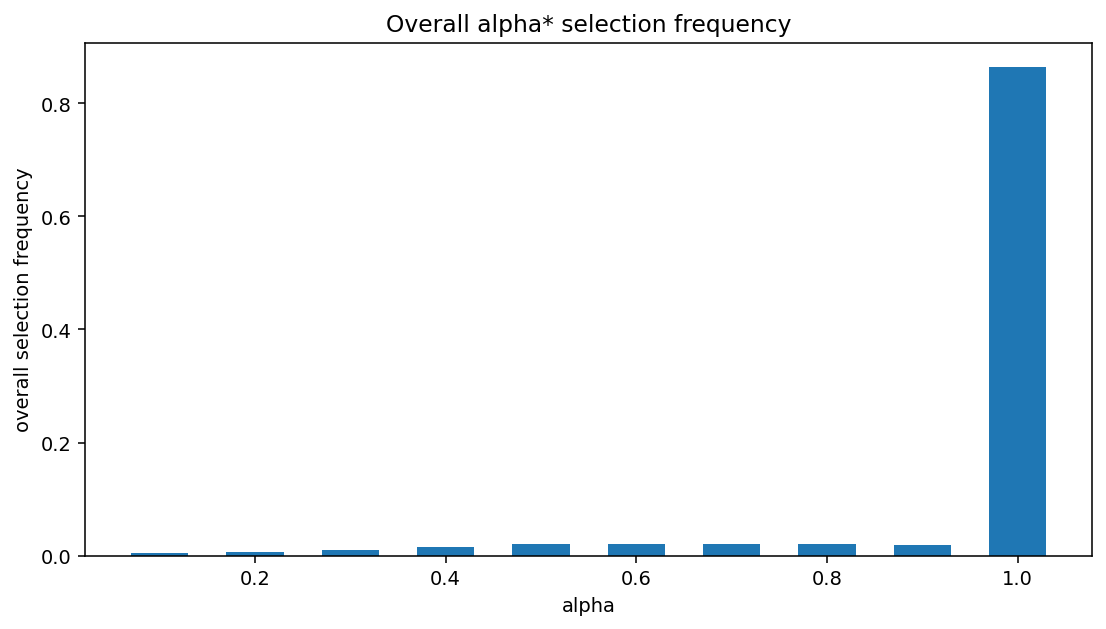

In [9]:
# 3) Alpha-star behavior
plt.figure(figsize=(9, 4.8))
plt.plot(x_ref, pointwise_alpha_star_mean)
plt.fill_between(
    x_ref,
    pointwise_alpha_star_mean - pointwise_alpha_star_sd,
    pointwise_alpha_star_mean + pointwise_alpha_star_sd,
    alpha=0.2,
)
plt.xlabel("x")
plt.ylabel("alpha_star")
plt.title("Pointwise selected alpha*(x): mean ± 1 sd across replications")
savefig("04_alpha_star_mean_sd.png")

plt.figure(figsize=(8, 4.6))
unique_alpha, counts = np.unique(alpha_star_mat, return_counts=True)
freq = counts / counts.sum()
plt.bar(unique_alpha, freq, width=0.06)
plt.xlabel("alpha")
plt.ylabel("overall selection frequency")
plt.title("Overall alpha* selection frequency")
savefig("05_alpha_star_frequency.png")

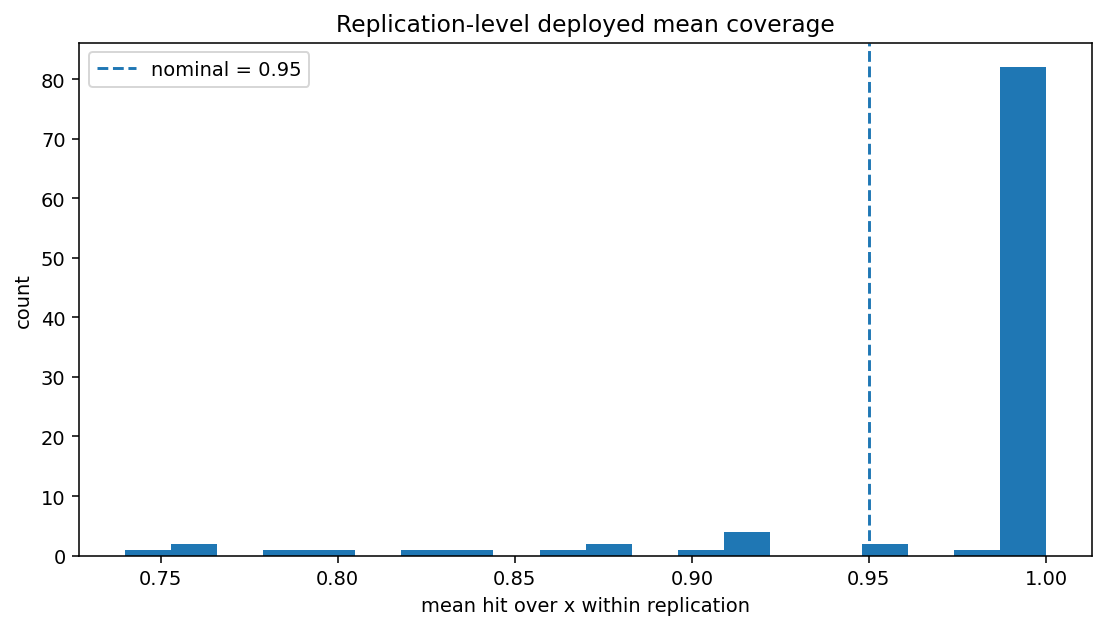

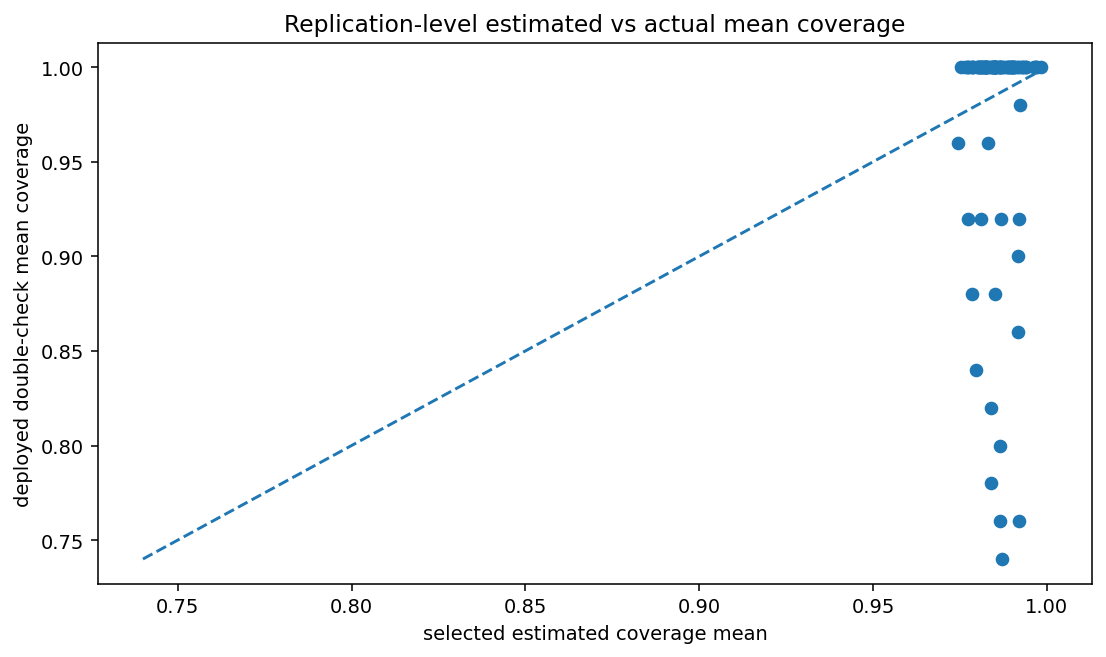

In [10]:
# 4) Replication-level diagnostics
plt.figure(figsize=(8, 4.6))
plt.hist(rep_level_df["deploy_mean_hit"], bins=min(20, max(5, R // 3)))
if ci_level is not None:
    plt.axvline(float(ci_level), linestyle="--", label=f"nominal = {ci_level:.2f}")
plt.xlabel("mean hit over x within replication")
plt.ylabel("count")
plt.title("Replication-level deployed mean coverage")
plt.legend()
savefig("06_replication_mean_coverage_hist.png")

if have_est_cov:
    plt.figure(figsize=(8, 4.8))
    plt.scatter(rep_level_df["selected_est_cov_mean"], rep_level_df["deploy_mean_hit"])
    lo = min(rep_level_df["selected_est_cov_mean"].min(), rep_level_df["deploy_mean_hit"].min())
    hi = max(rep_level_df["selected_est_cov_mean"].max(), rep_level_df["deploy_mean_hit"].max())
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.xlabel("selected estimated coverage mean")
    plt.ylabel("deployed double-check mean coverage")
    plt.title("Replication-level estimated vs actual mean coverage")
    savefig("07_replication_estimated_vs_actual_scatter.png")

In [11]:
# 5) Quick textual diagnostics
print("==== FINAL DOUBLE CHECK SUMMARY ====")
for k, v in summary.items():
    print(f"{k}: {v}")

if ci_level is not None:
    mae = float(np.mean(np.abs(pointwise_table["deploy_coverage"] - float(ci_level))))
    print(f"pointwise mean absolute error to nominal: {mae:.6f}")

if have_est_cov:
    gap_mean = float(np.mean(pointwise_table["deploy_minus_selected_est"]))
    gap_abs_mean = float(np.mean(np.abs(pointwise_table["deploy_minus_selected_est"])))
    print(f"mean(actual - estimated) across x: {gap_mean:.6f}")
    print(f"mean absolute |actual - estimated| across x: {gap_abs_mean:.6f}")

print()
print(f"Saved outputs to: {OUTPUT_DIR}")

==== FINAL DOUBLE CHECK SUMMARY ====
R: 100
J: 50
rep_id_min: 0
rep_id_max: 99
nominal: 0.95
overall_deploy_mean_hit: 0.976
rep_mean_hit_mean: 0.9760000000000001
rep_mean_hit_sd: 0.06023522912949555
overall_selected_est_cov_mean: 0.9857080000000001
overall_deploy_minus_est_mean: -0.009708000000000161
pointwise mean absolute error to nominal: 0.046800
mean(actual - estimated) across x: -0.009708
mean absolute |actual - estimated| across x: 0.022612

Saved outputs to: C:\Users\yangy\26 spring\with reference\familyfix\results\double_check_summary


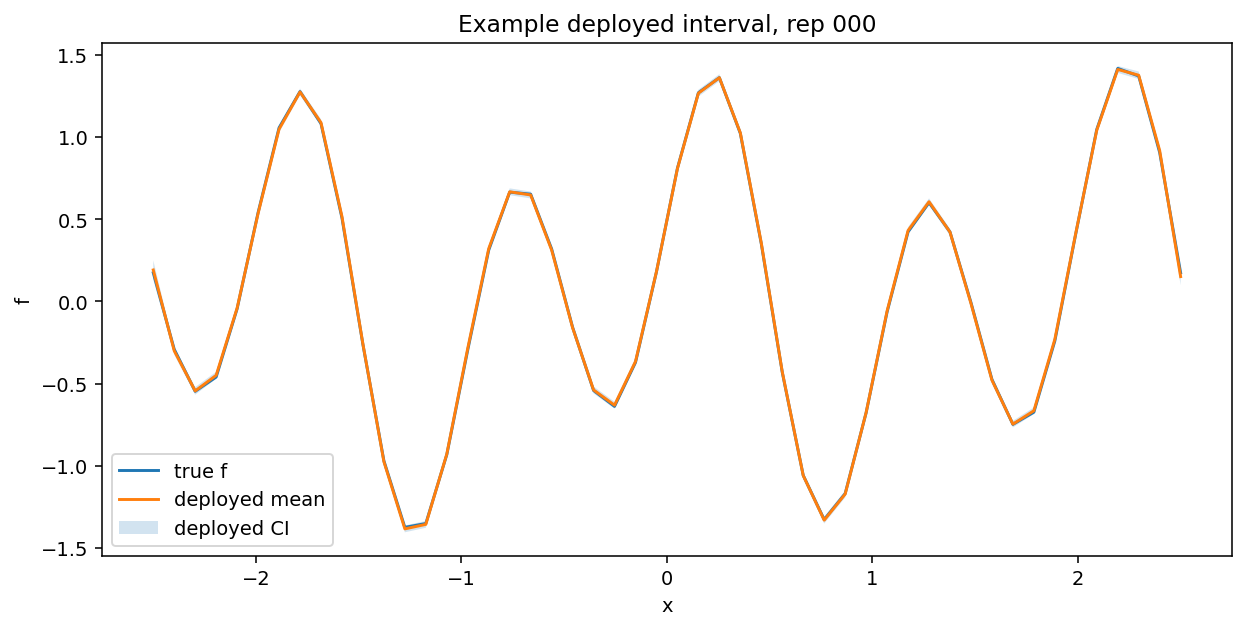

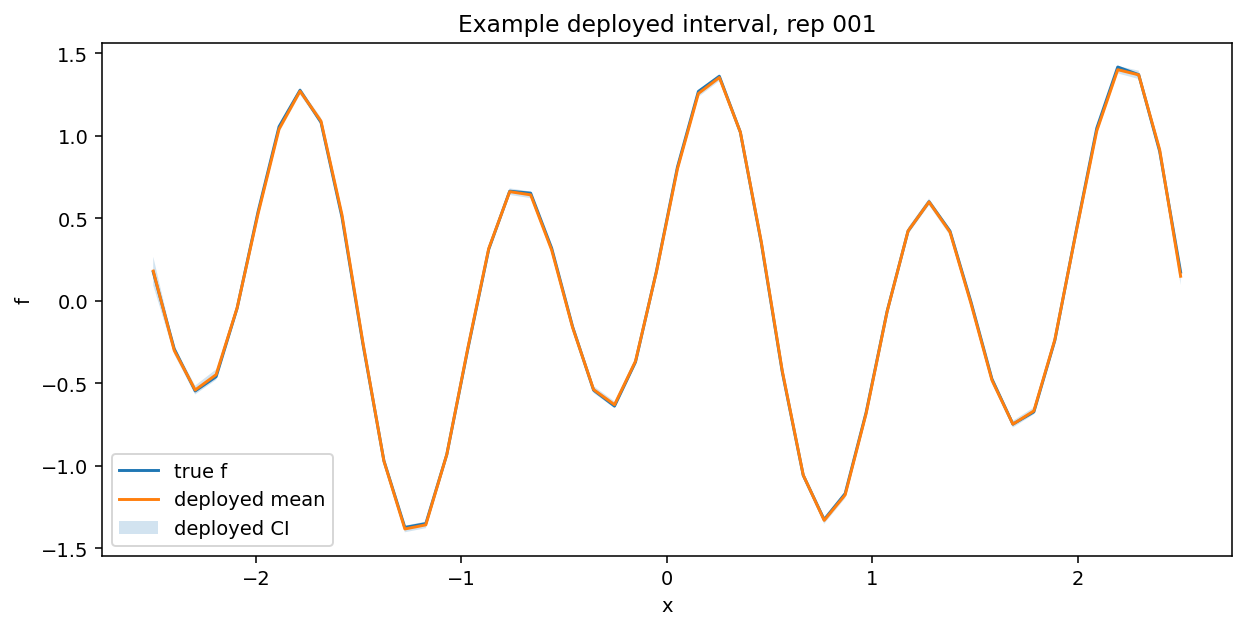

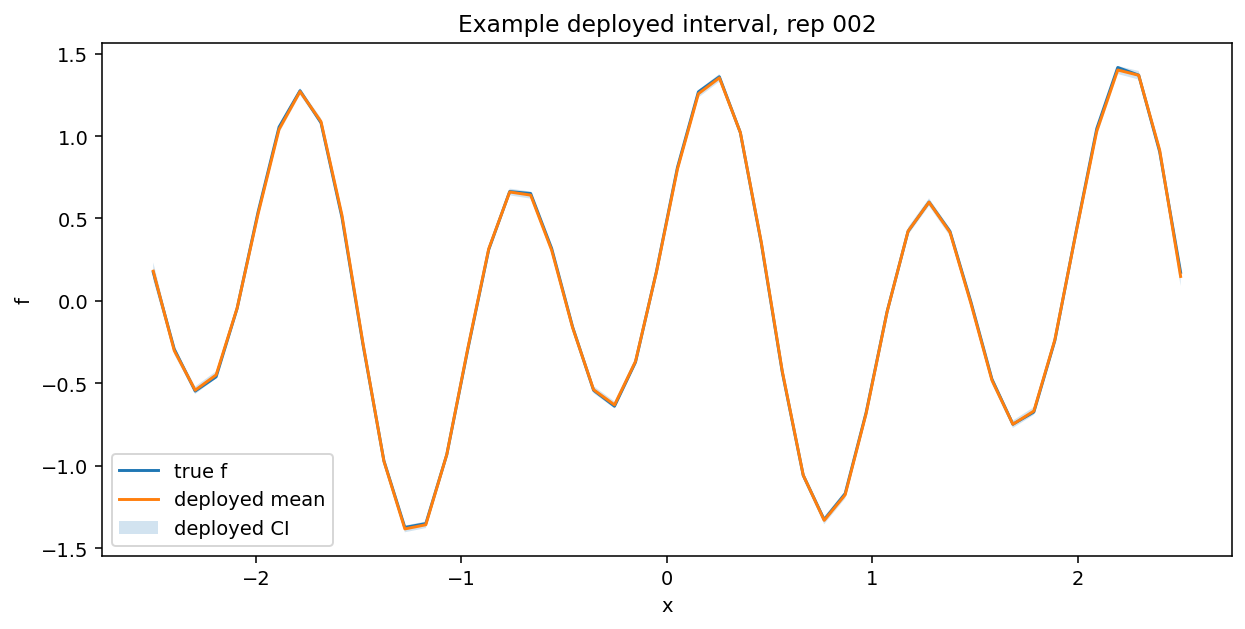

In [12]:
# Optional: inspect a few replications
example_reps = rep_ids[: min(3, len(rep_ids))]
for rep in example_reps:
    rec = next(r for r in records if r["rep_id"] == int(rep))
    df = rec["deploy_df"]
    plt.figure(figsize=(9, 4.6))
    plt.plot(df["x"], df["true_f"], label="true f")
    plt.plot(df["x"], df["mu"], label="deployed mean")
    plt.fill_between(df["x"], df["lower"], df["upper"], alpha=0.2, label="deployed CI")
    plt.title(f"Example deployed interval, rep {rep:03d}")
    plt.xlabel("x")
    plt.ylabel("f")
    plt.legend()
    plt.tight_layout()
    plt.show()